In [190]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

In [191]:
data1 = pd.read_csv("datasets/pawel_video_dataset.csv")
data2 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_1.csv")
data3 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_2.csv")
data4 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_3.csv")
data5 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_01_4.csv")
data6 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_1.csv")
data7 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_2.csv")
data8 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_3.csv")
data9 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_02_4.csv")
data10 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_03_1.csv")
data11 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_03_2.csv")
data12 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_03_3.csv")
data13 = pd.read_csv("datasets/pawel_video_dataset_multiplications/pawel_video_dataset_moved_03_4.csv")

data = pd.concat([data1, data2, data3, data4, data5, data6, data7, data8, data9, data10, data11, data12, data13], ignore_index=True)
anita_data = pd.read_csv("datasets/anita_video_dataset.csv")

In [192]:
X_train = data.iloc[:, :63]  # wszystkie kolumny oprócz ostatnich
y_train = data.iloc[:, 63:]  # tylko ostatnia kolumna

X_test = anita_data.iloc[:, :63]  # wszystkie kolumny oprócz ostatnich
y_test = anita_data.iloc[:, 63:]  # tylko ostatnia kolumna

In [197]:
# model = DecisionTreeClassifier(criterion='gini', splitter='random')
# model.fit(X_train, y_train)
model = joblib.load("models/decision_tree_gini_12_random.pkl")

Text(0.5, 1.0, 'Macierz Pomyłek')

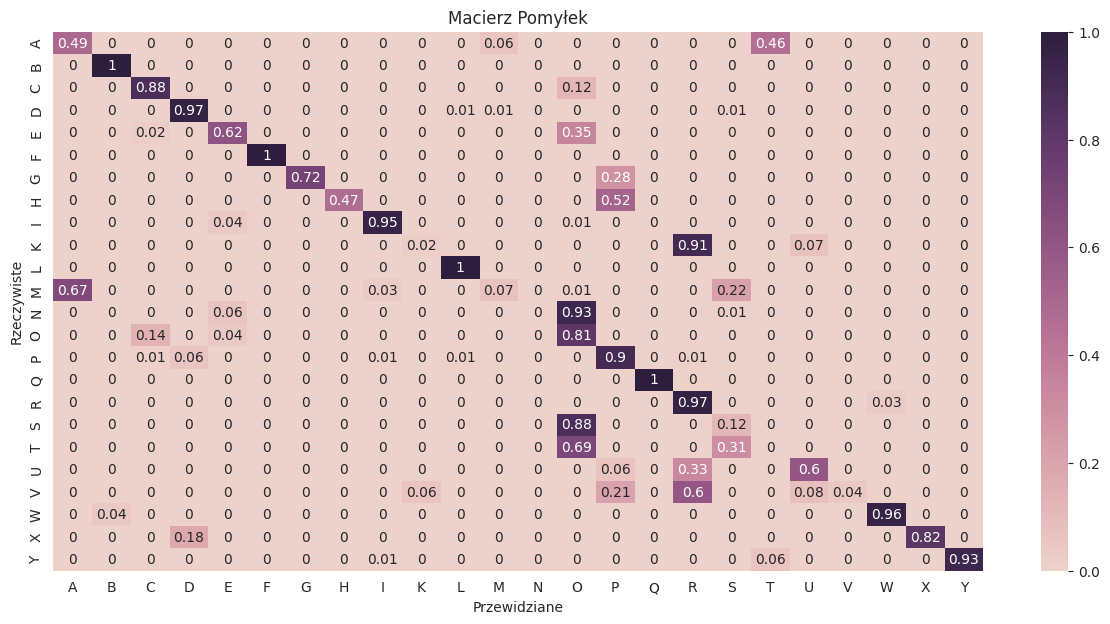

In [198]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm_dt = confusion_matrix(y_true, y_pred_classes)
cm_dt_normalized = cm_dt.astype('float') / 271
cm_dt_normalized_rounded = cm_dt_normalized.round(2)

plt.figure(figsize=(15, 7))
klasy = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W',
         'X', 'Y']
sns.heatmap(cm_dt_normalized_rounded, annot=True, fmt='g', cmap=sns.cubehelix_palette(as_cmap=True), xticklabels=klasy,
            yticklabels=klasy)
plt.plot()
plt.xlabel('Przewidziane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz Pomyłek')

In [199]:
result = 0
for i in range(24):
    result += 1 - cm_dt_normalized_rounded[i][i]
result

8.66

In [200]:
# joblib.dump(model, "models/decision_tree_gini_123_random.pkl")